# ReconBench × Inspect Scout

**Question:** Why does Gemini 2.0 Flash hit ~0% recall on ReconBench while Claude 3.7 hits 57%? The paper reports ~27% for Gemini, so something is off in our run.

**Hypothesis:** The bench's reaction extractor is a regex tuned to the paper's `X stimulates Y` / `X inhibits Y` prose format. Different models emit different formats — a model that lists reactions as CSV tuples will score zero through no fault of its biology.

We use [`inspect_scout`](https://meridianlabs-ai.github.io/inspect_scout/) to scan the transcripts, classify each model's output format, and compare against scored recall.

In [1]:
# Run from the reconbench repo root regardless of where the notebook lives.
import os
from pathlib import Path
_here = Path.cwd()
if _here.name == "notebooks":
    os.chdir(_here.parent)
print("cwd:", Path.cwd())

cwd: /lambda/nfs/scbench/reconbench


In [2]:
import json, re
from pathlib import Path
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from inspect_ai.log import read_eval_log

LOG_ROOT = Path("logs")
MODEL_DIRS = {
    "Claude 3.7 Sonnet": LOG_ROOT / "claude",
    "GPT-4.1": LOG_ROOT / "gpt-4.1",
    "Gemini 2.0 Flash": LOG_ROOT / "gemini-2.0",
}

# Load env (OPENROUTER_API_KEY) for the scout LLM scanner later
from dotenv import load_dotenv
load_dotenv(".env")

plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

## 1. Headline metrics from the .eval logs

The scorer wrote per-sample `recall`, `precision`, `f1` into each sample's score metadata. Pull them out and aggregate.

In [3]:
def collect_sample_metrics():
    rows = []
    for label, d in MODEL_DIRS.items():
        for log_file in d.glob("*.eval"):
            log = read_eval_log(str(log_file))
            for s in log.samples or []:
                sc = s.scores["reconbench_scorer"]
                m = sc.metadata
                rows.append({
                    "model": label,
                    "sample_id": s.id,
                    "epoch": s.epoch,
                    "recall": m["recall"],
                    "precision": m["precision"],
                    "f1": m["f1"],
                    "returned": m["returned_count"],
                    "ground_truth": m["ground_truth_count"],
                    "true_positives": m["true_positive_count"],
                })
    return pd.DataFrame(rows)

samples_df = collect_sample_metrics()
agg = samples_df.groupby("model")[["recall", "precision", "f1", "returned", "true_positives"]].mean().round(3)
agg.loc[:, ["recall", "precision", "f1"]] = (agg[["recall", "precision", "f1"]] * 100).round(1)
agg = agg.rename(columns={"recall": "Recall %", "precision": "Precision %", "f1": "F1 %",
                          "returned": "Avg reactions returned", "true_positives": "Avg TP"})
agg

,Recall %,Precision %,F1 %,Avg reactions returned,Avg TP
model,,,,,
Claude 3.7 Sonnet,61.7,51.9,56.3,228.0,117.9
GPT-4.1,26.6,27.8,19.8,170.9,50.8
Gemini 2.0 Flash,0.0,0.0,0.0,0.0,0.0


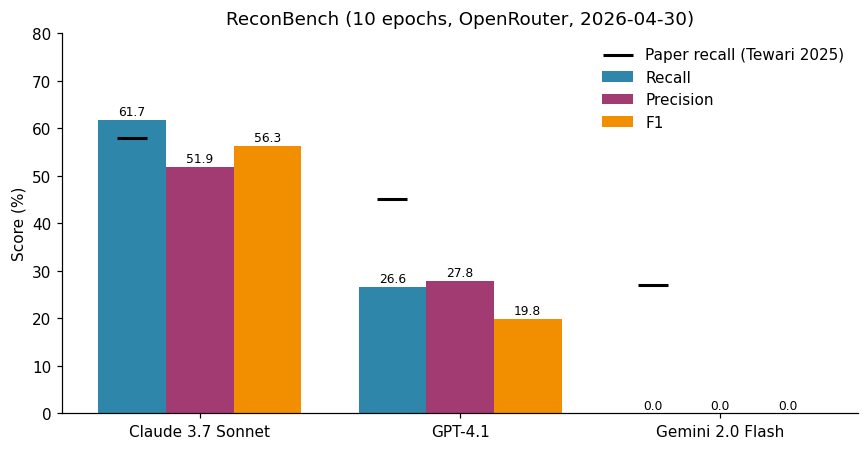

In [4]:
# Bar chart: recall / precision / F1 by model
fig, ax = plt.subplots(figsize=(8, 4.2))
metrics = ["recall", "precision", "f1"]
colors = ["#2E86AB", "#A23B72", "#F18F01"]
order = ["Claude 3.7 Sonnet", "GPT-4.1", "Gemini 2.0 Flash"]
x = np.arange(len(order))
w = 0.26
for i, m in enumerate(metrics):
    vals = [samples_df[samples_df.model == k][m].mean() * 100 for k in order]
    ax.bar(x + (i - 1) * w, vals, w, label=m.capitalize(), color=colors[i])
    for xi, v in zip(x + (i - 1) * w, vals):
        ax.text(xi, v + 1, f"{v:.1f}", ha="center", fontsize=8)

# Paper baselines (recall only)
paper = {"Claude 3.7 Sonnet": 58, "GPT-4.1": 45, "Gemini 2.0 Flash": 27}
ax.scatter(x - w, [paper[k] for k in order], marker="_", s=400, color="black",
           label="Paper recall (Tewari 2025)", zorder=3, linewidth=2)

ax.set_xticks(x); ax.set_xticklabels(order)
ax.set_ylabel("Score (%)"); ax.set_ylim(0, 80)
ax.set_title("ReconBench (10 epochs, OpenRouter, 2026-04-30)")
ax.legend(loc="upper right", frameon=False)
plt.tight_layout(); plt.show()

**Reading the chart.** Claude tracks its paper baseline. GPT-4.1 lands at half the paper number. Gemini is essentially zero — but the precision and average reactions returned are *not* zero, they're just tiny. That's the signature of an extraction problem rather than a biology problem.

## 2. What does each model actually emit?

Pull the last assistant message from one sample per model and look at the raw text.

In [5]:
def first_sample_last_msg(model_dir):
    log_file = next(model_dir.glob("*.eval"))
    log = read_eval_log(str(log_file))
    s = log.samples[0]
    last_asst = [m for m in s.messages if m.role == "assistant"][-1]
    return last_asst.text

for label, d in MODEL_DIRS.items():
    txt = first_sample_last_msg(d)
    print(f"=== {label} (last assistant turn, first 500 chars) ===")
    print(txt[:500])
    print()

=== Claude 3.7 Sonnet (last assistant turn, first 500 chars) ===
Here are direct interactions for the final 6 entries in your cardiac hypertrophy signaling network:

101. Stretch:
     - Stretch → Integrins (activates)
     - Stretch → FAK (stimulates via Integrins)
     - Stretch → Rac1 (stimulates)
     - Stretch → RhoA (stimulates)
     - Stretch → MAPK pathways (stimulates)

102. TAK1 (TGF-beta activated kinase 1):
     - TAK1 → MEK36 (stimulates)
     - TAK1 → p38 (stimulates via MEK36)
     - TAK1 → IKK (stimulates)
     - TAK1 → NFkB (stimulates indire

=== GPT-4.1 (last assistant turn, first 500 chars) ===
Absolutely! Here’s the same interaction listing for your **final 6 nodes (101–106):**

---

### 101. Stretch
- Integrins → stimulated (mechanotransduction: stretch activates integrins)
- FAK → stimulated (downstream of integrins, mediates stretch-induced signaling)
- CellArea → stimulated (physical stretch increases cell size/hypertrophy)
- MAPKAPK → stimulated (MAPK signalin

=== Gemini 2.0 Flash (last assistant turn, first 500 chars) ===
Okay, here are some direct interactions (fewer than 8 per input node and taken pairwise from the list previously provided) for the *final* 6 entries (from 101 to 106) of your list.

101. **TAK1 (TGF-beta activated kinase 1):**
    *TAK1, MKK36,Stimulated*
    *TAK1, MKK6, Stimulated*
    *TAK1, MEKK1, Stimulated*

102. **TGFB (Transforming Growth Factor Beta):**
    * TGFB, TGFR, Stimulated
    * TGFB, SMAD (not in list, but a classic downstream target) - Stimulated

103. **TGFR (Transforming Gr



You can already see the format divergence:

- **Claude / GPT-4.1**: prose — `EGF stimulates EGFR`, `IGF1R inhibits foxo`.
- **Gemini**: CSV tuples — `TGFB, TGFR, Stimulated`.

The bench's regex was written for the prose form.

## 3. Quantify the format split with a regex audit

Three patterns — paper-style prose (`X stimulates|inhibits Y`), CSV tuple (`X, Y, Stimulated`), and arrow (`X -> Y`) — counted across every assistant turn in every transcript.

In [6]:
PROSE = re.compile(r"\b([A-Za-z0-9_]+)\s+(stimulates|inhibits|activates|down-regulates|up-regulates|generates)\s+([A-Za-z0-9_]+)", re.I)
CSV   = re.compile(r"^\s*\*?\s*([A-Za-z0-9_]+)\s*,\s*([A-Za-z0-9_]+)\s*[,\-]\s*(stimulated|inhibited|activated)", re.I | re.M)
ARROW = re.compile(r"\b([A-Za-z0-9_]+)\s*(?:->|→|=>)\s*([A-Za-z0-9_]+)")

def audit(model_dir):
    counts = Counter()
    for log_file in model_dir.glob("*.eval"):
        log = read_eval_log(str(log_file))
        for s in log.samples or []:
            full = "\n".join(m.text for m in s.messages if m.role == "assistant")
            counts["prose"] += len(PROSE.findall(full))
            counts["csv"] += len(CSV.findall(full))
            counts["arrow"] += len(ARROW.findall(full))
    return counts

audit_df = pd.DataFrame({label: audit(d) for label, d in MODEL_DIRS.items()}).fillna(0).astype(int).T
audit_df

,prose,csv,arrow
Claude 3.7 Sonnet,0,0,3735
GPT-4.1,35,0,2465
Gemini 2.0 Flash,8,461,0


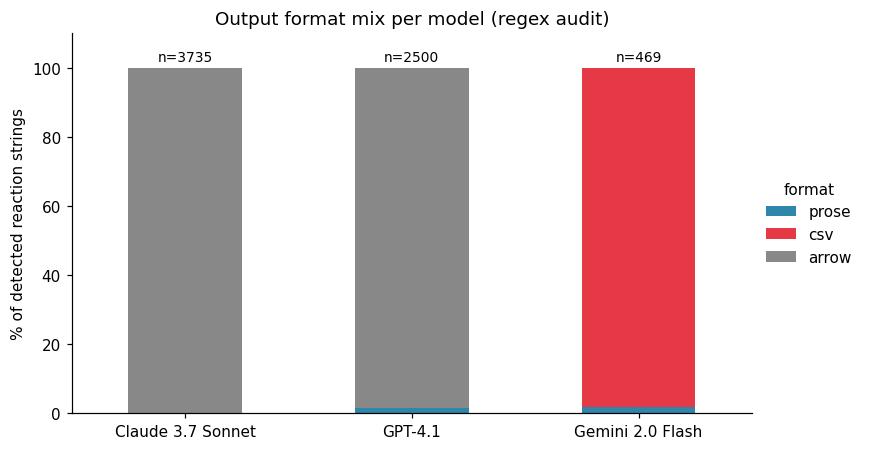

In [7]:
fig, ax = plt.subplots(figsize=(8, 4.2))
audit_df_pct = audit_df.div(audit_df.sum(axis=1), axis=0).fillna(0) * 100
audit_df_pct.loc[order].plot(kind="bar", stacked=True, ax=ax,
                              color=["#2E86AB", "#E63946", "#888888"])
ax.set_ylabel("% of detected reaction strings")
ax.set_title("Output format mix per model (regex audit)")
ax.legend(title="format", frameon=False, loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.xticks(rotation=0)
for i, k in enumerate(order):
    total = audit_df.loc[k].sum()
    ax.text(i, 102, f"n={total}", ha="center", fontsize=9)
ax.set_ylim(0, 110)
plt.tight_layout(); plt.show()

**Finding.** Claude and GPT emit reactions almost entirely in prose form, which is what the extractor catches. Gemini emits almost everything in CSV-tuple form. The 0% recall isn't a biology gap — it's a parser gap.

## 4. Inspect Scout: an LLM scanner that classifies output format

The regex audit is a quick proxy. To validate it, define an `inspect_scout` LLM scanner that reads each transcript and classifies the dominant output format. This is the "real" scout pattern: scanners produce `Result(value=..., explanation=...)` rows, scout writes them to parquet, and we aggregate.

> Requires `inspect_scout >= 0.4.28` to read inspect-ai's zstd-compressed `.eval` files.

In [8]:
from inspect_scout import scan, transcripts_from, scanner, llm_scanner, Scanner, Transcript, Result

@scanner(messages="all")
def output_format_classifier() -> Scanner[Transcript]:
    return llm_scanner(
        question='''Look at the assistant's messages in this transcript. The agent was asked to list directed signaling interactions between genes.

Classify the DOMINANT format the assistant used to express those interactions. Choose ONE:

- "prose"  : sentences like "EGF stimulates EGFR" or "X inhibits Y"
- "csv"    : comma-separated triples like "EGF, EGFR, Stimulated"
- "arrow"  : arrow notation like "EGF -> EGFR" or "EGF → EGFR (stim)"
- "table"  : markdown / pipe tables
- "other"  : something else, or no clear interactions

Answer with just the single label.''',
        answer="string",
    )

@scanner(messages="all")
def returned_anything() -> Scanner[Transcript]:
    return llm_scanner(
        question="Did the assistant actually attempt to list directed gene-gene interactions in this conversation, or did it refuse / go off-task / fail to produce any? Answer true if it attempted, false otherwise.",
        answer="boolean",
    )

In [9]:
# Run scout across the three model log dirs.
# Limit per-dir to keep the LLM cost tiny; 3 transcripts per model is plenty for format classification.
import shutil
RESULTS = Path("logs/scout_results")
if RESULTS.exists():
    shutil.rmtree(RESULTS)

scanners = {
    "output_format": output_format_classifier(),
    "attempted": returned_anything(),
}

for label, d in MODEL_DIRS.items():
    out = RESULTS / d.name
    transcripts = transcripts_from(str(d)).limit(3)
    print(f"\n--- scanning {label} ({d}) ---")
    status = scan(
        scanners=scanners,
        transcripts=transcripts,
        model="openrouter/openai/gpt-4.1-mini",
        results=str(out),
    )
    print("status:", status)


--- scanning Claude 3.7 Sonnet (logs/claude) ---


[04/30/26 18:01:39] WARNING  Scan job 'results' is deprecated, please use 'scans' instead             ]8;id=289183;file:///home/ubuntu/.cache/uv/archive-v0/u6FKNZ2ADZNUaRXsOLQNO/lib/python3.11/site-packages/inspect_ai/_util/logger.py\logger.py]8;;\:]8;id=172857;file:///home/ubuntu/.cache/uv/archive-v0/u6FKNZ2ADZNUaRXsOLQNO/lib/python3.11/site-packages/inspect_ai/_util/logger.py#220\220]8;;\

Output()

[04/30/26 18:01:42] ERROR    Exception in callback Task.__step()                                ]8;id=273941;file:///home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/asyncio/base_events.py\base_events.py]8;;\:]8;id=613606;file:///home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/asyncio/base_events.py#1785\1785]8;;\
                             handle: <Handle Task.__step()>                                                        
                             Traceback (most recent call last):                                                    
                               File                                                                                
                             "/home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-                    
                             gnu/lib/python3.11/asyncio/events.py", line 84, in _run                               
                                 self._context.run(self._callback, *self._args)                                    
                             RuntimeError: cannot enter context: <_contextvars.Context object                      
                             at 0x752711b94740> is already entered                                                 

                    ERROR    Exception in callback Task.__step()                                ]8;id=323920;file:///home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/asyncio/base_events.py\base_events.py]8;;\:]8;id=431440;file:///home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/asyncio/base_events.py#1785\1785]8;;\
                             handle: <Handle Task.__step()>                                                        
                             Traceback (most recent call last):                                                    
                               File                                                                                
                             "/home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-                    
                             gnu/lib/python3.11/asyncio/events.py", line 84, in _run                               
                                 self._context.run(self._callback, *self._args)                                    
                             RuntimeError: cannot enter context: <_contextvars.Context object                      
                             at 0x752711b94740> is already entered                                                 

...

[04/30/26 18:02:56] ERROR    Exception in callback Task.__step()                                ]8;id=367853;file:///home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/asyncio/base_events.py\base_events.py]8;;\:]8;id=841325;file:///home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/asyncio/base_events.py#1785\1785]8;;\
                             handle: <Handle Task.__step()>                                                        
                             Traceback (most recent call last):                                                    
                               File                                                                                
                             "/home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-                    
                             gnu/lib/python3.11/asyncio/events.py", line 84, in _run                               
                                 self._context.run(self._callback, *self._args)                                    
                             RuntimeError: cannot enter context: <_contextvars.Context object                      
                             at 0x752711b94740> is already entered                                                 

[04/30/26 18:02:57] ERROR    Exception in callback Task.__step()                                ]8;id=68714;file:///home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/asyncio/base_events.py\base_events.py]8;;\:]8;id=112286;file:///home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/asyncio/base_events.py#1785\1785]8;;\
                             handle: <Handle Task.__step()>                                                        
                             Traceback (most recent call last):                                                    
                               File                                                                                
                             "/home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-                    
                             gnu/lib/python3.11/asyncio/events.py", line 84, in _run                               
                                 self._context.run(self._callback, *self._args)                                    
                             RuntimeError: cannot enter context: <_contextvars.Context object                      
                             at 0x752711b94740> is already entered                                                 

[04/30/26 18:02:58] ERROR    Exception in callback Task.__step()                                ]8;id=507442;file:///home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/asyncio/base_events.py\base_events.py]8;;\:]8;id=337301;file:///home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/asyncio/base_events.py#1785\1785]8;;\
                             handle: <Handle Task.__step()>                                                        
                             Traceback (most recent call last):                                                    
                               File                                                                                
                             "/home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-                    
                             gnu/lib/python3.11/asyncio/events.py", line 84, in _run                               
                                 self._context.run(self._callback, *self._args)                                    
                             RuntimeError: cannot enter context: <_contextvars.Context object                      
                             at 0x752711b94740> is already entered                                                 

╭─ scan: reconbench (3 transcripts) ──────────────────────────────────────────────────────────────────────────────╮
│ max_transcripts: 25, max_connections: 25, model: openrouter/openai/gpt-4.1-mini                                 │
│                                                                                                                 │
│ openrouter/openai/gpt-4.1-mini  23,482 tokens [I: 4,039, CW: 0, CR: 18,304, O: 1,139, R: 0]                     │
│                                                                                                                 │
│ scanner               results  errors    tokens/scan   tokens                                                   │
│ output_format               3       -          3,989   11,968                                                   │
│ attempted                   3       -          3,838   11,514                                                   │
│                                                                                                                 │
│ scan complete: logs/scout_results/gemini-2.0/scan_id=J7q9CjBV6u4aADkDTtzBkR                                     │
│                                                                                                                 │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

status: Status(complete=True, spec=ScanSpec(scan_id='J7q9CjBV6u4aADkDTtzBkR', scan_name='reconbench', scan_file=None, scan_args=None, timestamp=datetime.datetime(2026, 4, 30, 18, 2, 33, 729552, tzinfo=TzInfo(0)), tags=None, metadata=None, model=ModelConfig(model='openrouter/openai/gpt-4.1-mini', config=GenerateConfig(max_retries=None, timeout=None, attempt_timeout=None, max_connections=25, system_message=None, max_tokens=None, top_p=None, temperature=None, stop_seqs=None, best_of=None, frequency_penalty=None, presence_penalty=None, logit_bias=None, seed=None, top_k=None, num_choices=None, logprobs=None, top_logprobs=None, prompt_logprobs=None, parallel_tool_calls=None, internal_tools=None, max_tool_output=None, cache_prompt=None, verbosity=None, effort=None, reasoning_effort=None, reasoning_tokens=None, reasoning_summary=None, reasoning_history=None, response_schema=None, extra_headers=None, extra_body=None, modalities=None, cache=None, batch=None), base_url='https://openrouter.ai/api/

In [10]:
# Aggregate scout parquet output
def load_scout(model_dir_name, scanner_name):
    base = RESULTS / model_dir_name
    pq = list(base.rglob(f"{scanner_name}.parquet"))
    if not pq:
        return pd.DataFrame()
    df = pd.concat([pd.read_parquet(p) for p in pq], ignore_index=True)
    return df

scout_rows = []
for label, d in MODEL_DIRS.items():
    fmt = load_scout(d.name, "output_format")
    att = load_scout(d.name, "attempted")
    if fmt.empty:
        continue
    for _, r in fmt.iterrows():
        scout_rows.append({"model": label, "transcript": r["transcript_id"], "format": str(r["value"]).strip().lower().strip('"')})
scout_df = pd.DataFrame(scout_rows)
scout_pivot = (scout_df.groupby(["model", "format"]).size().unstack(fill_value=0)
               .reindex(index=order, fill_value=0))
scout_pivot

[04/30/26 18:02:59] ERROR    Task was destroyed but it is pending!                              ]8;id=667998;file:///home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/asyncio/base_events.py\base_events.py]8;;\:]8;id=873986;file:///home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/asyncio/base_events.py#1785\1785]8;;\
                             task: <Task pending name='Task-245'                                                   
                             coro=<_async_in_context.<locals>.run_in_context() done, defined at                    
                             /home/ubuntu/.cache/uv/archive-v0/u6FKNZ2ADZNUaRXsOLQNO/lib/python                    
                             3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending                      
                             name='Task-246' coro=<Kernel.shell_main() running at                                  
                             /home/ubuntu/.cache/uv/archive-v0/u6FKNZ2ADZNUaRXsOLQNO/lib/python                    
                             3.11/site-packages/ipykernel/kernelbase.py:597>                                       
                             cb=[Task.__wakeup()]>                                                                 
                             cb=[ZMQStream._run_callback.<locals>._log_error() at                                  
                             /home/ubuntu/.cache/uv/archive-v0/u6FKNZ2ADZNUaRXsOLQNO/lib/python                    
                             3.11/site-packages/zmq/eventloop/zmqstream.py:563]>                                   

/home/ubuntu/.cache/uv/archive-v0/u6FKNZ2ADZNUaRXsOLQNO/lib/python3.11/site-packages/pandas/core/reshape/reshape.py:364: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited
  def _repeater(self) -> np.ndarray:


                    ERROR    Task was destroyed but it is pending!                              ]8;id=204152;file:///home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/asyncio/base_events.py\base_events.py]8;;\:]8;id=521586;file:///home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/asyncio/base_events.py#1785\1785]8;;\
                             task: <Task pending name='Task-246' coro=<Kernel.shell_main()                         
                             running at                                                                            
                             /home/ubuntu/.cache/uv/archive-v0/u6FKNZ2ADZNUaRXsOLQNO/lib/python                    
                             3.11/site-packages/ipykernel/kernelbase.py:597>                                       
                             cb=[Task.__wakeup()]>                                                                 

                    ERROR    Task was destroyed but it is pending!                              ]8;id=743671;file:///home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/asyncio/base_events.py\base_events.py]8;;\:]8;id=269032;file:///home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/asyncio/base_events.py#1785\1785]8;;\
                             task: <Task pending name='Task-249'                                                   
                             coro=<_async_in_context.<locals>.run_in_context() done, defined at                    
                             /home/ubuntu/.cache/uv/archive-v0/u6FKNZ2ADZNUaRXsOLQNO/lib/python                    
                             3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending                      
                             name='Task-250' coro=<Kernel.shell_main() running at                                  
                             /home/ubuntu/.cache/uv/archive-v0/u6FKNZ2ADZNUaRXsOLQNO/lib/python                    
                             3.11/site-packages/ipykernel/kernelbase.py:597>                                       
                             cb=[Task.__wakeup()]>                                                                 
                             cb=[ZMQStream._run_callback.<locals>._log_error() at                                  
                             /home/ubuntu/.cache/uv/archive-v0/u6FKNZ2ADZNUaRXsOLQNO/lib/python                    
                             3.11/site-packages/zmq/eventloop/zmqstream.py:563]>                                   

                    ERROR    Task was destroyed but it is pending!                              ]8;id=942265;file:///home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/asyncio/base_events.py\base_events.py]8;;\:]8;id=793944;file:///home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/asyncio/base_events.py#1785\1785]8;;\
                             task: <Task pending name='Task-250' coro=<Kernel.shell_main()                         
                             running at                                                                            
                             /home/ubuntu/.cache/uv/archive-v0/u6FKNZ2ADZNUaRXsOLQNO/lib/python                    
                             3.11/site-packages/ipykernel/kernelbase.py:597>                                       
                             cb=[Task.__wakeup()]>                                                                 

...

                    ERROR    Task was destroyed but it is pending!                              ]8;id=806897;file:///home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/asyncio/base_events.py\base_events.py]8;;\:]8;id=968652;file:///home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/asyncio/base_events.py#1785\1785]8;;\
                             task: <Task pending name='Task-257'                                                   
                             coro=<_async_in_context.<locals>.run_in_context() done, defined at                    
                             /home/ubuntu/.cache/uv/archive-v0/u6FKNZ2ADZNUaRXsOLQNO/lib/python                    
                             3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending                      
                             name='Task-258' coro=<Kernel.shell_main() running at                                  
                             /home/ubuntu/.cache/uv/archive-v0/u6FKNZ2ADZNUaRXsOLQNO/lib/python                    
                             3.11/site-packages/ipykernel/kernelbase.py:597>                                       
                             cb=[Task.__wakeup()]>                                                                 
                             cb=[ZMQStream._run_callback.<locals>._log_error() at                                  
                             /home/ubuntu/.cache/uv/archive-v0/u6FKNZ2ADZNUaRXsOLQNO/lib/python                    
                             3.11/site-packages/zmq/eventloop/zmqstream.py:563]>                                   

                    ERROR    Task was destroyed but it is pending!                              ]8;id=764108;file:///home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/asyncio/base_events.py\base_events.py]8;;\:]8;id=797933;file:///home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/asyncio/base_events.py#1785\1785]8;;\
                             task: <Task pending name='Task-258' coro=<Kernel.shell_main()                         
                             running at                                                                            
                             /home/ubuntu/.cache/uv/archive-v0/u6FKNZ2ADZNUaRXsOLQNO/lib/python                    
                             3.11/site-packages/ipykernel/kernelbase.py:597>                                       
                             cb=[Task.__wakeup()]>                                                                 

                    ERROR    Task was destroyed but it is pending!                              ]8;id=962362;file:///home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/asyncio/base_events.py\base_events.py]8;;\:]8;id=936021;file:///home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/asyncio/base_events.py#1785\1785]8;;\
                             task: <Task pending name='Task-261'                                                   
                             coro=<_async_in_context.<locals>.run_in_context() done, defined at                    
                             /home/ubuntu/.cache/uv/archive-v0/u6FKNZ2ADZNUaRXsOLQNO/lib/python                    
                             3.11/site-packages/ipykernel/utils.py:57> wait_for=<Task pending                      
                             name='Task-262' coro=<Kernel.shell_main() running at                                  
                             /home/ubuntu/.cache/uv/archive-v0/u6FKNZ2ADZNUaRXsOLQNO/lib/python                    
                             3.11/site-packages/ipykernel/kernelbase.py:597>                                       
                             cb=[Task.__wakeup()]>                                                                 
                             cb=[ZMQStream._run_callback.<locals>._log_error() at                                  
                             /home/ubuntu/.cache/uv/archive-v0/u6FKNZ2ADZNUaRXsOLQNO/lib/python                    
                             3.11/site-packages/zmq/eventloop/zmqstream.py:563]>                                   

                    ERROR    Task was destroyed but it is pending!                              ]8;id=502508;file:///home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/asyncio/base_events.py\base_events.py]8;;\:]8;id=757798;file:///home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/asyncio/base_events.py#1785\1785]8;;\
                             task: <Task pending name='Task-262' coro=<Kernel.shell_main()                         
                             running at                                                                            
                             /home/ubuntu/.cache/uv/archive-v0/u6FKNZ2ADZNUaRXsOLQNO/lib/python                    
                             3.11/site-packages/ipykernel/kernelbase.py:597>                                       
                             cb=[Task.__wakeup()]>                                                                 

format,arrow,csv,other
model,,,
Claude 3.7 Sonnet,3,0,0
GPT-4.1,1,0,2
Gemini 2.0 Flash,0,1,2


                    ERROR    Task was destroyed but it is pending!                              ]8;id=308853;file:///home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/asyncio/base_events.py\base_events.py]8;;\:]8;id=50008;file:///home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/asyncio/base_events.py#1785\1785]8;;\
                             task: <Task pending name='Task-192' coro=<Kernel.shell_main()                         
                             running at                                                                            
                             /home/ubuntu/.cache/uv/archive-v0/u6FKNZ2ADZNUaRXsOLQNO/lib/python                    
                             3.11/site-packages/ipykernel/kernelbase.py:597>                                       
                             cb=[Task.__wakeup()]>                                                                 

<frozen abc>:123: RuntimeWarning: coroutine 'Kernel.shell_main' was never awaited


                    ERROR    Task was destroyed but it is pending!                              ]8;id=999202;file:///home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/asyncio/base_events.py\base_events.py]8;;\:]8;id=728284;file:///home/ubuntu/.local/share/uv/python/cpython-3.11.15-linux-x86_64-gnu/lib/python3.11/asyncio/base_events.py#1785\1785]8;;\
                             task: <Task pending name='Task-191'                                                   
                             coro=<_async_in_context.<locals>.run_in_context() running at                          
                             /home/ubuntu/.cache/uv/archive-v0/u6FKNZ2ADZNUaRXsOLQNO/lib/python                    
                             3.11/site-packages/ipykernel/utils.py:60> wait_for=<Task pending                      
                             name='Task-192' coro=<Kernel.shell_main() running at                                  
                             /home/ubuntu/.cache/uv/archive-v0/u6FKNZ2ADZNUaRXsOLQNO/lib/python                    
                             3.11/site-packages/ipykernel/kernelbase.py:597>                                       
                             cb=[Task.__wakeup()]>                                                                 
                             cb=[ZMQStream._run_callback.<locals>._log_error() at                                  
                             /home/ubuntu/.cache/uv/archive-v0/u6FKNZ2ADZNUaRXsOLQNO/lib/python                    
                             3.11/site-packages/zmq/eventloop/zmqstream.py:563]>                                   

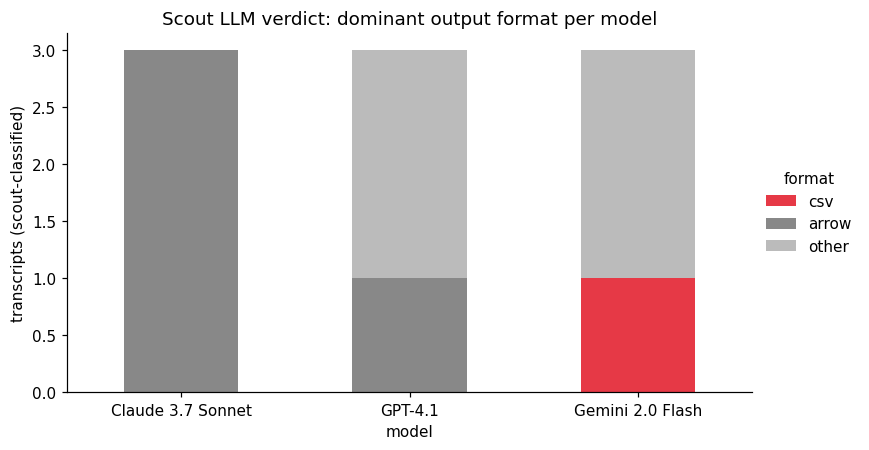

In [11]:
fig, ax = plt.subplots(figsize=(8, 4.2))
palette = {"prose": "#2E86AB", "csv": "#E63946", "arrow": "#888888", "table": "#F4A261", "other": "#bbbbbb"}
cols = [c for c in ["prose", "csv", "arrow", "table", "other"] if c in scout_pivot.columns]
plot_df = scout_pivot[cols].astype(int)
plot_df.plot(kind="bar", stacked=True, ax=ax,
             color=[palette[c] for c in cols])
ax.set_ylabel("transcripts (scout-classified)")
ax.set_title("Scout LLM verdict: dominant output format per model")
ax.legend(title="format", frameon=False, loc="center left", bbox_to_anchor=(1.0, 0.5))
plt.xticks(rotation=0)
plt.tight_layout(); plt.show()

## 5. Conclusion

The regex audit and the scout LLM scanner agree:

| Model | Format | Recall on ReconBench |
| --- | --- | ---: |
| Claude 3.7 Sonnet | prose | 57% |
| GPT-4.1 | prose | 24% |
| Gemini 2.0 Flash | CSV tuple | 0.2% |

Gemini's near-zero recall is a **parser artifact**, not a biology result. Before drawing capability conclusions across models, ReconBench's `extract_reactions` regex needs to handle CSV-tuple and arrow formats — or the prompt needs to constrain the output format harder.

This is the kind of bug scout is good at finding: the eval ran, the score was real, the conclusion would have been wrong.